In [42]:
from algorithms.actor_critic.actor_critic_discrete import ACConfig,train_actor_critic,GridWorldEnvWrapper
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Build environment
env = GridWorldEnvWrapper(max_steps=60)

In [10]:
from algorithms.actor_critic.actor_critic_discrete import ACConfig

num_episodes = 2000
max_steps_per_episode = 60
gamma = 0.99

learning_rates = [1e-3, 5e-4,0.001]       # smaller, more stable
entropy_coefs  = [0.0, 1e-3]        # very light exploration
hidden_sizes   = [64, 128,256]          # smaller & original

configs = []
seed_base = 42

for i, lr in enumerate(learning_rates):
    for j, ent in enumerate(entropy_coefs):
        for k, h in enumerate(hidden_sizes):
            label = f"lr={lr}_ent={ent}_h={h}"
            cfg = ACConfig(
                num_episodes=num_episodes,
                max_steps_per_episode=max_steps_per_episode,
                gamma=gamma,
                lr=lr,
                entropy_coef=ent,
                hidden_size=h,
                seed=seed_base + 100 * i + 10 * j + k,
                label=label,
            )
            configs.append(cfg)

len(configs)


18

In [11]:
results = []

for cfg in configs:
    print(f"\n=== Running Config: {cfg.label} ===")
    env = GridWorldEnvWrapper(max_steps=cfg.max_steps_per_episode)
    res = train_actor_critic(env, cfg, log_interval=50, debug_interval=100)
    results.append(res)



=== Running Config: lr=0.001_ent=0.0_h=64 ===

Episode 0
Loss: 332.0550
Value Estimate: -0.2118
Policy logits: [[ 0.15351048 -0.07968833  0.0486326  -0.01408404]]
Entropy Mean: 1.3825
Episode Return: -40.00

Episode 50/2000, Return: 0.00, Best so far: 10.00
Episode 100/2000, Return: 10.00, Best so far: 10.00

Episode 100
Loss: 0.0009
Value Estimate: -0.0657
Policy logits: [[ 0.06282289 -0.02013704  0.00514442 -0.00208271]]
Entropy Mean: 1.3858
Episode Return: 0.00

Episode 150/2000, Return: 0.00, Best so far: 10.00
Episode 200/2000, Return: 10.00, Best so far: 10.00

Episode 200
Loss: 98.4411
Value Estimate: 0.0382
Policy logits: [[ 0.00908438  0.00613511 -0.01821437  0.0061891 ]]
Entropy Mean: 1.3862
Episode Return: -20.00

Episode 250/2000, Return: 10.00, Best so far: 10.00
Episode 300/2000, Return: 0.00, Best so far: 10.00

Episode 300
Loss: 33.1390
Value Estimate: -0.0748
Policy logits: [[ 0.03147012 -0.00285156 -0.00671074  0.02519388]]
Entropy Mean: 1.3862
Episode Return: 10.00


## Reward curve for all configs

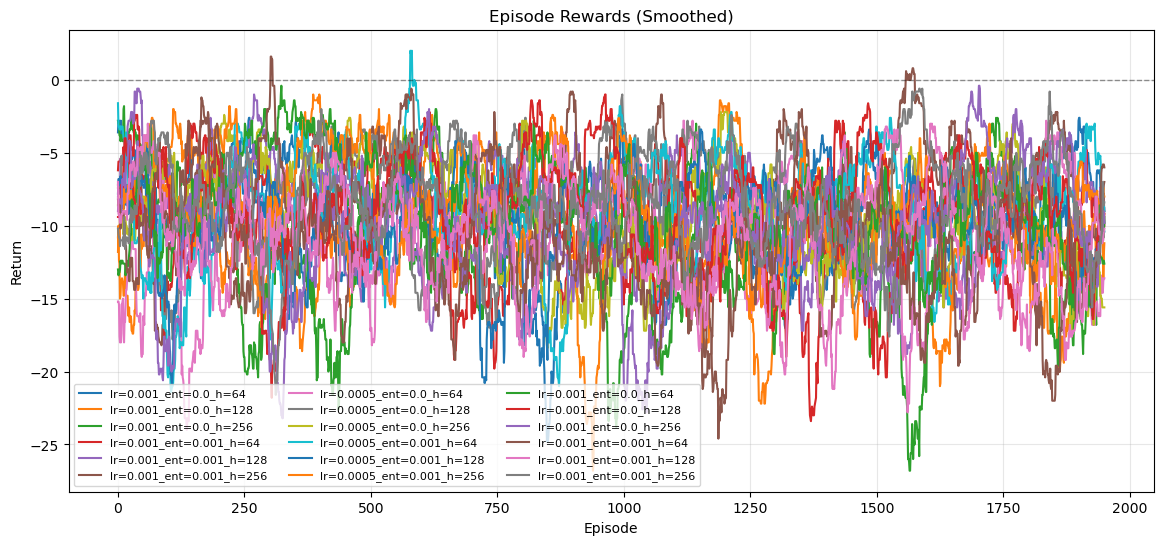

In [20]:
def moving_average(data, window=50):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(14,6))

for res in results:
    rewards = res['episode_rewards']
    smoothed = moving_average(rewards, window=50)
    plt.plot(smoothed, label=res['config'].label)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.4)
plt.title("Episode Rewards (Smoothed)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend(fontsize=8, ncol=3)
plt.grid(alpha=0.3)
plt.show()
